In [1]:
import pandas as pd
import numpy as np

from scipy.stats import (
    ttest_ind,
    chi2_contingency,
    pointbiserialr,
    zscore
)
import os
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
churn = pd.read_csv('../data/raw/gym_churn_1M_dataset.csv', sep=',', na_values=[''], quotechar='"')
churn

,Member_ID,Age,Gender,Membership_Type,Membership_Start_Date,Monthly_Fee,Monthly_Visits,Avg_Workout_Duration_Min,Peak_Hour_Preference,Cardio_Preference,Treadmill_Avg_Speed_Kmh,Treadmill_Avg_Incline_Pct,Group_Class_Attendance,PT_Session_Count,Supplement_Usage,Avg_Equipment_Wait_Time_Min,Late_Payment_Count,Profile_Type,Churn
0,1,17,Male,Premium,2025-08-20,74.61,10,76,Evening (17-21),Cycling,NaN,NaN,5,0,NaN,16.7,5,Casual,1
1,2,57,Male,Premium,2023-10-18,73.89,3,40,Evening (17-21),Treadmill,13.9,3.2,12,0,Full Stack,9.7,0,Drop-out,0
2,3,26,Female,Standard,2024-08-20,27.77,12,62,Late Night (21-24),Cycling,NaN,NaN,12,0,Whey Protein,23.0,6,Regular,0
3,4,25,Male,Standard,2024-01-28,28.90,5,58,Midday (10-14),Treadmill,8.7,12.1,11,0,Whey Protein,22.3,0,Casual,0
4,5,26,Male,Gold,2025-03-21,48.41,24,40,Late Night (21-24),Rowing,NaN,NaN,3,2,Pre-Workout,22.6,2,Casual,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,999996,55,Male,Standard,2024-11-18,29.98,10,57,Midday (10-14),Rowing,NaN,NaN,10,0,Pre-Workout,24.2,0,Casual,0
999996,999997,34,Female,Gold,2025-02-21,49.00,2,112,Evening (17-21),Cycling,NaN,NaN,0,0,NaN,12.7,2,Drop-out,0
999997,999998,18,Male,Gold,2024-02-08,49.32,18,46,Morning (6-10),Cycling,NaN,NaN,7,2,NaN,15.9,6,Regular,1
999998,999999,21,Female,Gold,2025-06-01,49.63,8,54,Evening (17-21),Cycling,NaN,NaN,4,0,Whey Protein,9.6,3,Casual,0


| 컬럼명                           | 설명                | Type               |
| ----------------------------- | ----------------- |---------------- |
| `Member_ID`                   | 고유 회원 식별자         | int64 |
| `Age`                         | 고객 연령             | int64 |
| `Gender`                      | 성별 범주             | str|
| `Membership_Type`             | 헬스장 회원권 플랜        |str|
| `Membership_Start_Date`       | 멤버십 시작일           |str|
| `Monthly_Fee`                 | 월간 구독료            |float64|
| `Monthly_Visits`              | 월간 방문 횟수          |int64 |
| `Avg_Workout_Duration_Min`    | 평균 운동 시간(분)       |int64 |
| `Peak_Hour_Preference`        | 선호하는 헬스장 이용 시간    |str|
| `Cardio_Preference`           | 선호하는 유산소 운동 기구    |str|
| `Treadmill_Avg_Speed_Kmh`     | 러닝머신 평균 속도(km/h)  |float64|
| `Treadmill_Avg_Incline_Pct`   | 러닝머신 평균 경사도(%)    |float64|
| `Group_Class_Attendance`      | 그룹 수업 참여 횟수       |int64 |
| `PT_Session_Count`            | 개인 트레이너(PT) 세션 횟수 |int64 |
| `Supplement_Usage`            | 보충제 사용 여부/범주      |str|
| `Avg_Equipment_Wait_Time_Min` | 평균 장비 대기 시간(분)    |float64|
| `Late_Payment_Count`          | 연체 건수             |int64|
| `Profile_Type`                | 시뮬레이션된 고객 프로필_    |str|
|`Churn`| 이탈(0/1)|int64|


In [3]:
# 데이터 정보 확인

churn.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 19 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   Member_ID                    1000000 non-null  int64  
 1   Age                          1000000 non-null  int64  
 2   Gender                       1000000 non-null  str    
 3   Membership_Type              1000000 non-null  str    
 4   Membership_Start_Date        1000000 non-null  str    
 5   Monthly_Fee                  1000000 non-null  float64
 6   Monthly_Visits               1000000 non-null  int64  
 7   Avg_Workout_Duration_Min     1000000 non-null  int64  
 8   Peak_Hour_Preference         1000000 non-null  str    
 9   Cardio_Preference            773315 non-null   str    
 10  Treadmill_Avg_Speed_Kmh      337598 non-null   float64
 11  Treadmill_Avg_Incline_Pct    337598 non-null   float64
 12  Group_Class_Attendance       1000000 non-null  int64  

In [4]:
print(f'컬럼명:\n {churn.columns.values.tolist()}')
print(f'데이터 행: {churn.shape[0]}, 열: {churn.shape[1]}')


컬럼명:
 ['Member_ID', 'Age', 'Gender', 'Membership_Type', 'Membership_Start_Date', 'Monthly_Fee', 'Monthly_Visits', 'Avg_Workout_Duration_Min', 'Peak_Hour_Preference', 'Cardio_Preference', 'Treadmill_Avg_Speed_Kmh', 'Treadmill_Avg_Incline_Pct', 'Group_Class_Attendance', 'PT_Session_Count', 'Supplement_Usage', 'Avg_Equipment_Wait_Time_Min', 'Late_Payment_Count', 'Profile_Type', 'Churn']
데이터 행: 1000000, 열: 19


In [5]:
# 전처리 전 데이터 타입 확인

churn.dtypes.value_counts()

int64      8
str        7
float64    4
Name: count, dtype: int64

In [6]:
# 결측치 확인

churn.isna().sum()

Member_ID                           0
Age                                 0
Gender                              0
Membership_Type                     0
Membership_Start_Date               0
Monthly_Fee                         0
Monthly_Visits                      0
Avg_Workout_Duration_Min            0
Peak_Hour_Preference                0
Cardio_Preference              226685
Treadmill_Avg_Speed_Kmh        662402
Treadmill_Avg_Incline_Pct      662402
Group_Class_Attendance              0
PT_Session_Count                    0
Supplement_Usage               419573
Avg_Equipment_Wait_Time_Min         0
Late_Payment_Count                  0
Profile_Type                        0
Churn                               0
dtype: int64

In [7]:
# 결측치 처리

# Cardio_Preference
# 유산소 운동을 선호하지 않는 회원으로 간주
churn["Cardio_Preference"] = churn["Cardio_Preference"].fillna("No Preference")

# Treadmill_Avg_Speed_Kmh
# 결측치 비율이 높아 삭제가 어려우므로 중앙값으로 대체
churn["Treadmill_Avg_Speed_Kmh"] = churn["Treadmill_Avg_Speed_Kmh"].fillna(
    churn["Treadmill_Avg_Speed_Kmh"].median()
)

# Treadmill_Avg_Incline_Pct
# 결측치 비율이 높아 삭제가 어려우므로 중앙값으로 대체
churn["Treadmill_Avg_Incline_Pct"] = churn["Treadmill_Avg_Incline_Pct"].fillna(
    churn["Treadmill_Avg_Incline_Pct"].median()
)

# Supplement_Usage
# 보충제를 사용하지 않는 회원으로 간주
churn["Supplement_Usage"] = churn["Supplement_Usage"].fillna("No Protein Supplements")

In [8]:
# 결측치 재확인

churn.isna().sum()

Member_ID                      0
Age                            0
Gender                         0
Membership_Type                0
Membership_Start_Date          0
Monthly_Fee                    0
Monthly_Visits                 0
Avg_Workout_Duration_Min       0
Peak_Hour_Preference           0
Cardio_Preference              0
Treadmill_Avg_Speed_Kmh        0
Treadmill_Avg_Incline_Pct      0
Group_Class_Attendance         0
PT_Session_Count               0
Supplement_Usage               0
Avg_Equipment_Wait_Time_Min    0
Late_Payment_Count             0
Profile_Type                   0
Churn                          0
dtype: int64

In [9]:
# 멤버 고유 ID 중복 데이터 확인

churn["Member_ID"].duplicated().sum()

np.int64(0)

In [10]:
# `Member_ID`는 고유번호이므로 분석에 의미가 적어 제거

churn = churn.drop('Member_ID', axis=1)

In [11]:
numeric_cols = churn.select_dtypes(include="number").columns

outlier_result = []

for col in numeric_cols:
    Q1 = churn[col].quantile(0.25)
    Q3 = churn[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((churn[col] < lower) | (churn[col] > upper)).sum()

    outlier_result.append({
        "Column": col,
        "Outlier_Count": count,
        "Outlier_Ratio(%)": round(count / len(churn) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_result)

outlier_df

,Column,Outlier_Count,Outlier_Ratio(%)
0,Age,58968,5.90
1,Monthly_Fee,0,0.00
2,Monthly_Visits,25120,2.51
3,Avg_Workout_Duration_Min,0,0.00
4,Treadmill_Avg_Speed_Kmh,334774,33.48
5,Treadmill_Avg_Incline_Pct,335350,33.53
6,Group_Class_Attendance,0,0.00
7,PT_Session_Count,241998,24.20
8,Avg_Equipment_Wait_Time_Min,0,0.00
9,Late_Payment_Count,0,0.00


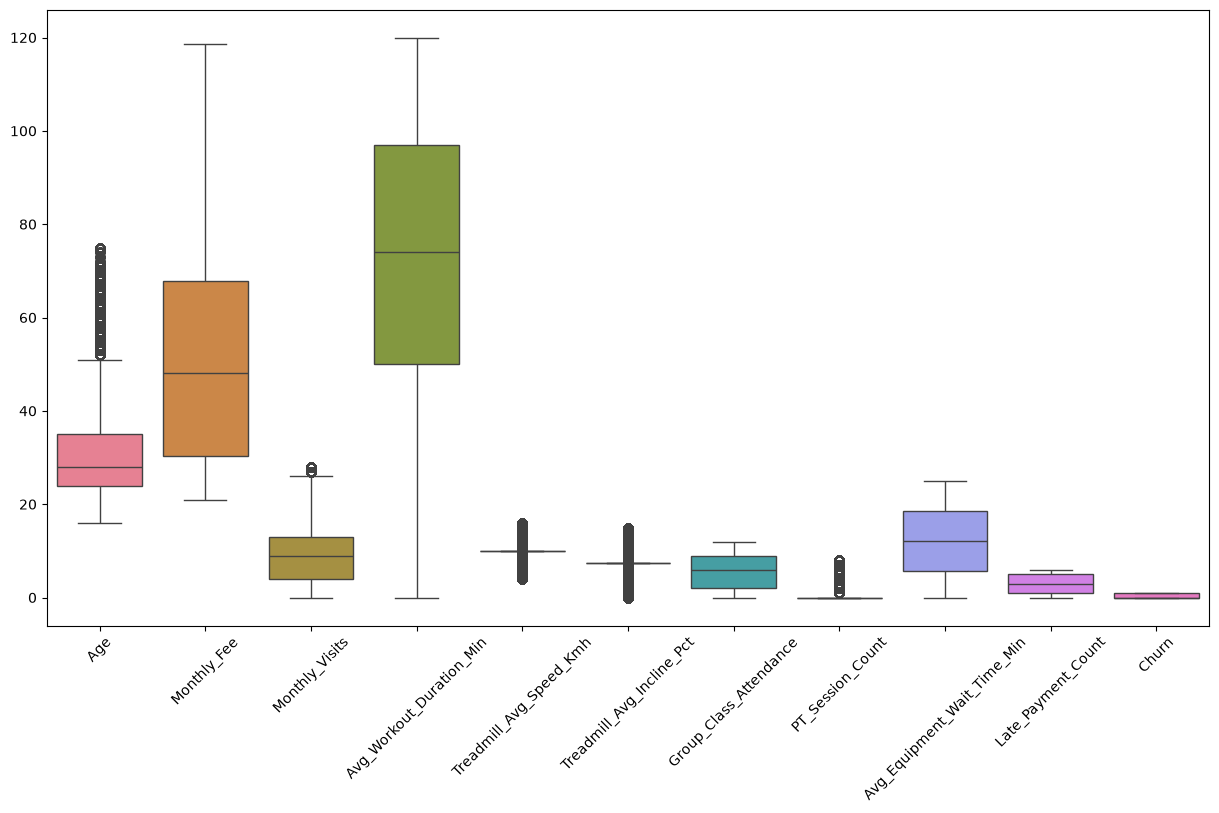

In [12]:
numeric_cols = churn.select_dtypes(include='number').columns

plt.figure(figsize=(15, 8))
sns.boxplot(data=churn[numeric_cols])
plt.xticks(rotation=45)
plt.show()

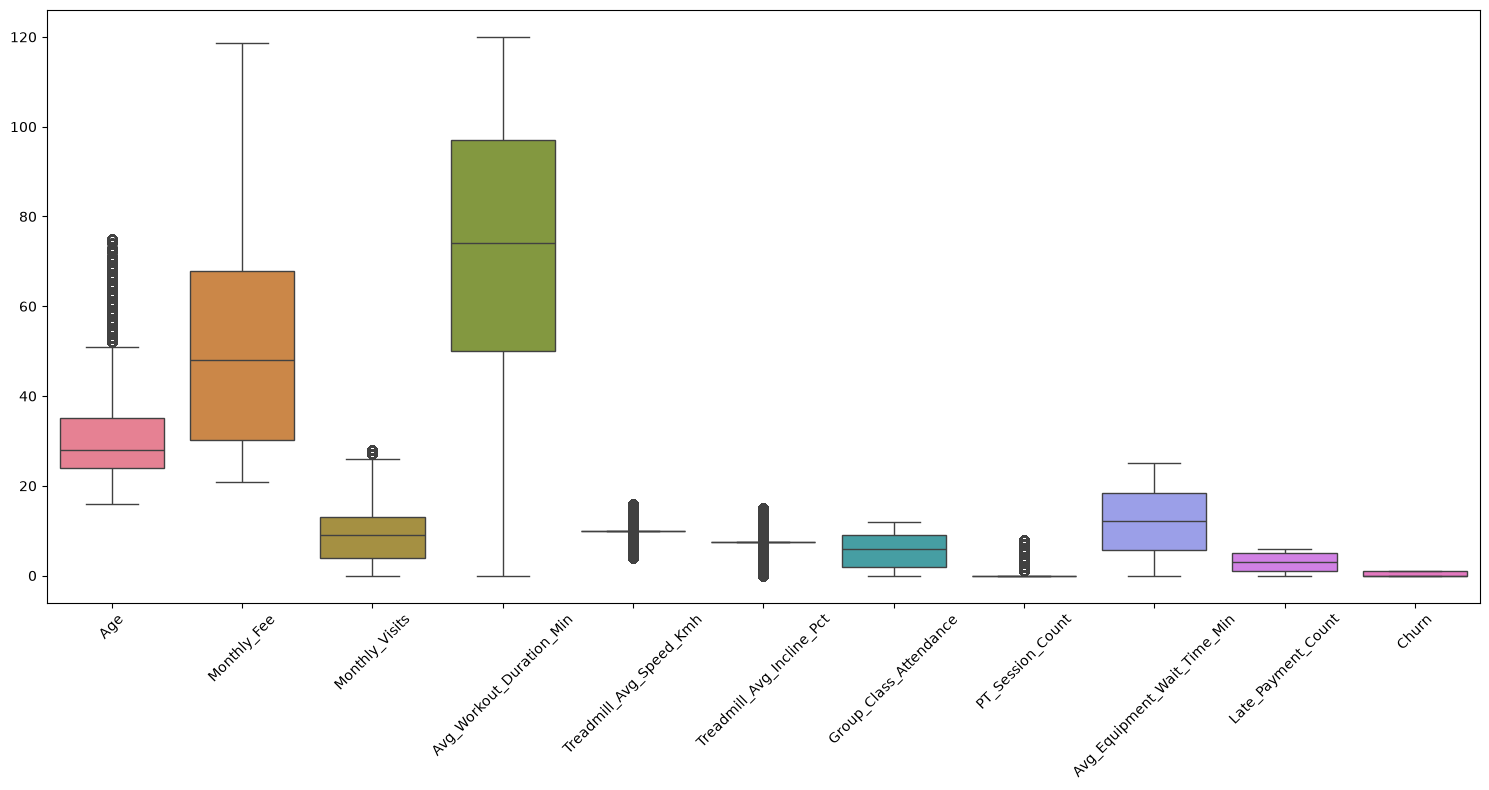

In [13]:
# boxplot 저장

save_dir = "../data/eda"
os.makedirs(save_dir, exist_ok=True)

numeric_cols = churn.select_dtypes(include="number").columns

plt.figure(figsize=(15, 8))
sns.boxplot(data=churn[numeric_cols])

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    os.path.join(save_dir, "boxplot.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

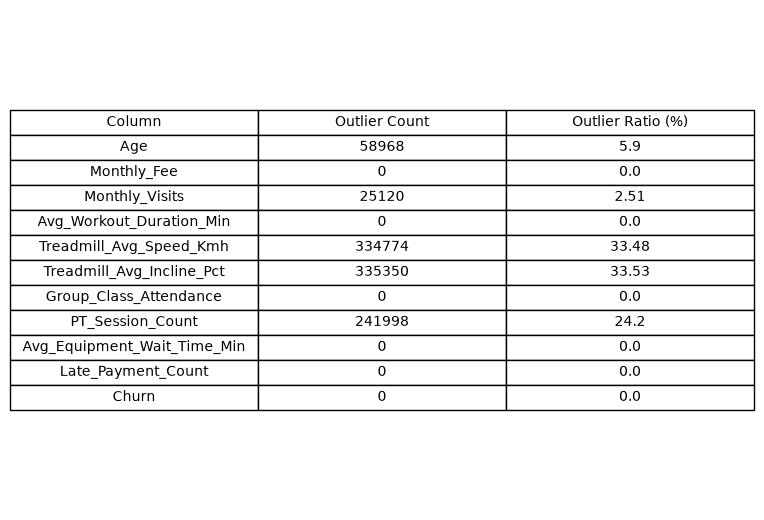

In [14]:
# IQR 결과(이미지) 저장

save_dir = "../data/eda"
os.makedirs(save_dir, exist_ok=True)

numeric_cols = churn.select_dtypes(include="number").columns

result = []

for col in numeric_cols:
    Q1 = churn[col].quantile(0.25)
    Q3 = churn[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_count = ((churn[col] < lower) | (churn[col] > upper)).sum()

    result.append([
        col,
        outlier_count,
        round(outlier_count / len(churn) * 100, 2)
    ])

iqr_df = pd.DataFrame(
    result,
    columns=["Column", "Outlier Count", "Outlier Ratio (%)"]
)

fig, ax = plt.subplots(figsize=(8, len(iqr_df) * 0.5 + 1))
ax.axis("off")

table = ax.table(
    cellText=iqr_df.values,
    colLabels=iqr_df.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

plt.savefig(
    os.path.join(save_dir, "iqr_result.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

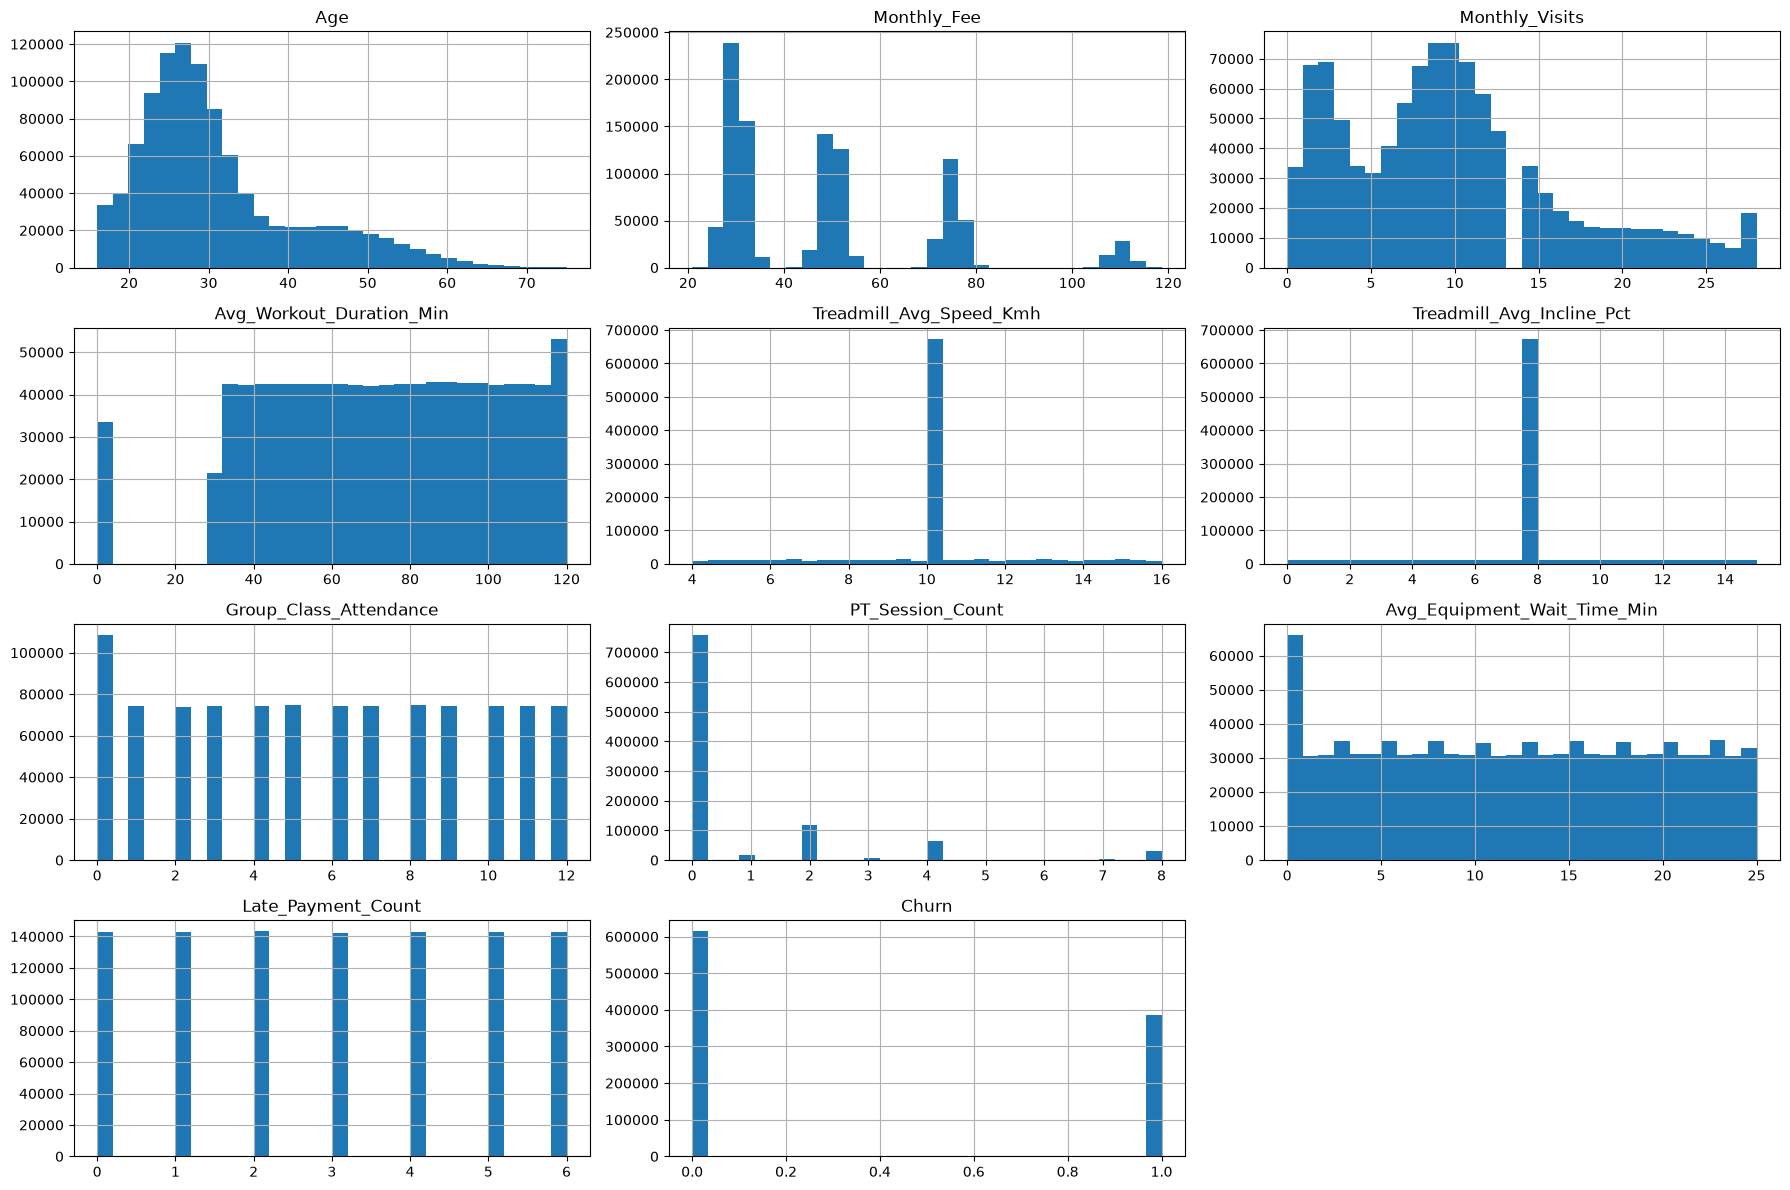

In [15]:
# 수치형 데이터 컬럼 선택
# 예: Age, Monthly_Fee, Monthly_Visits 등
numeric_cols = churn.select_dtypes(include="number").columns

# 각 수치형 변수의 분포 확인
# bins : 히스토그램 구간 개수
churn[numeric_cols].hist(
    figsize=(18, 12),
    bins=30
)

plt.tight_layout()
plt.show()

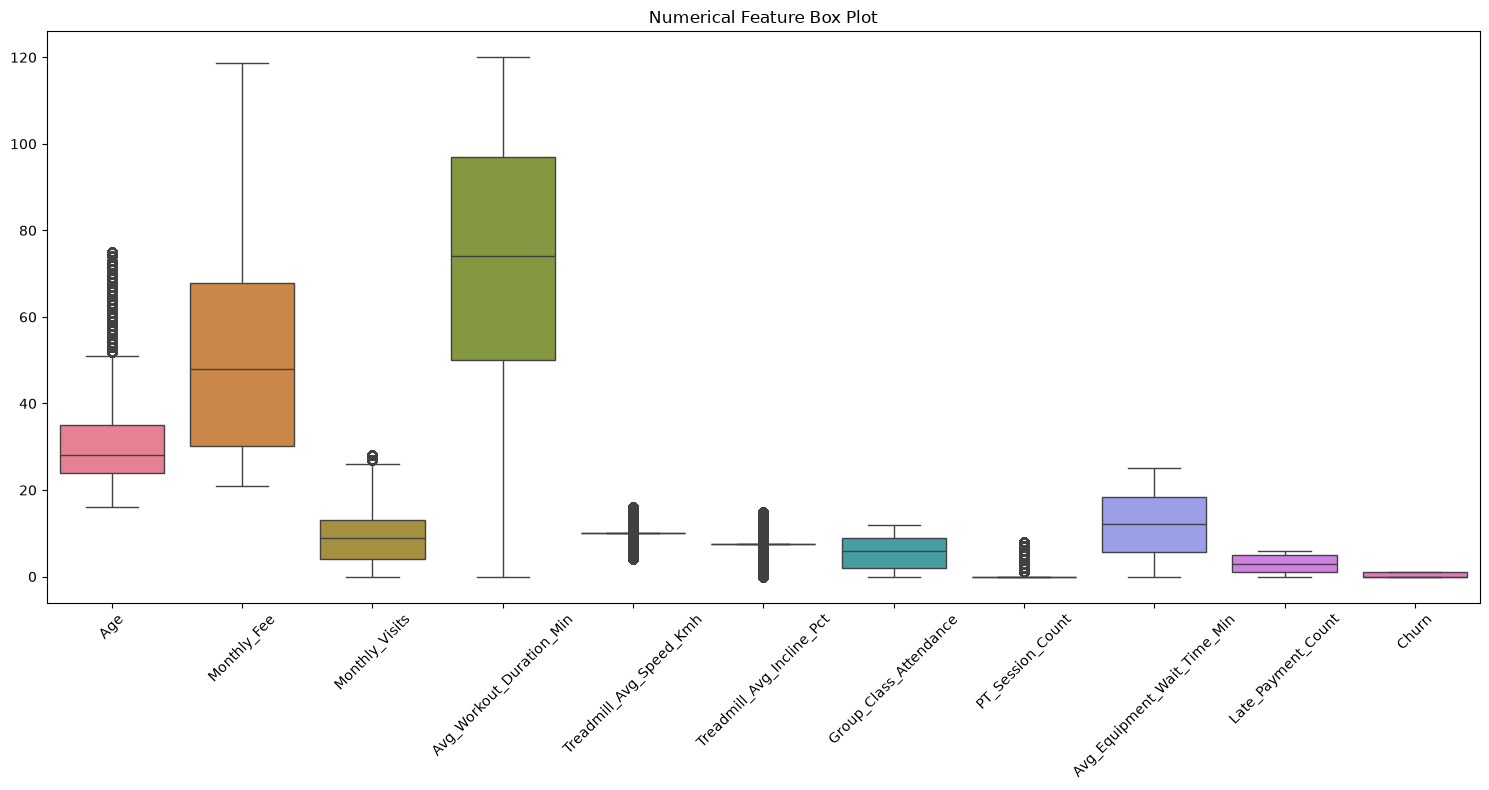

In [16]:
# 수치형 변수들의 이상치 및 분포 확인
plt.figure(figsize=(15, 8))

sns.boxplot(
    data=churn[numeric_cols]
)

# 컬럼명이 겹치지 않도록 회전
plt.xticks(rotation=45)

plt.title("Numerical Feature Box Plot")

plt.tight_layout()
plt.show()

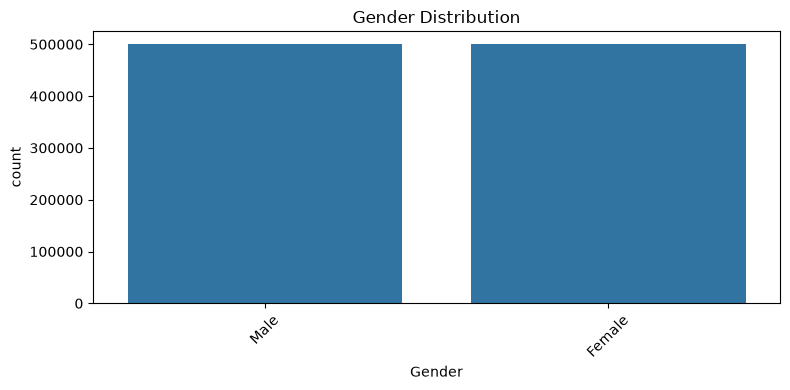

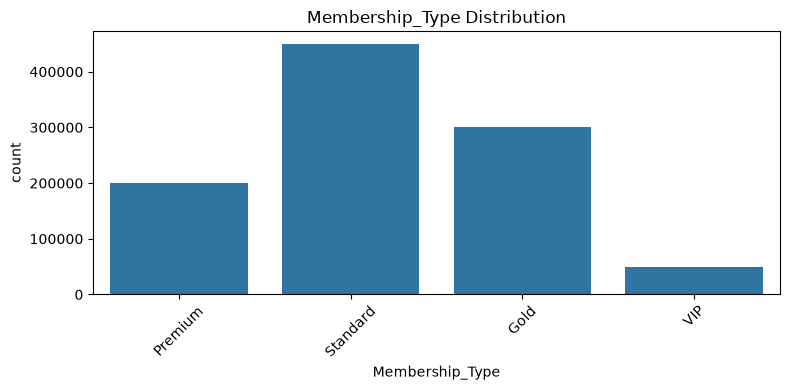

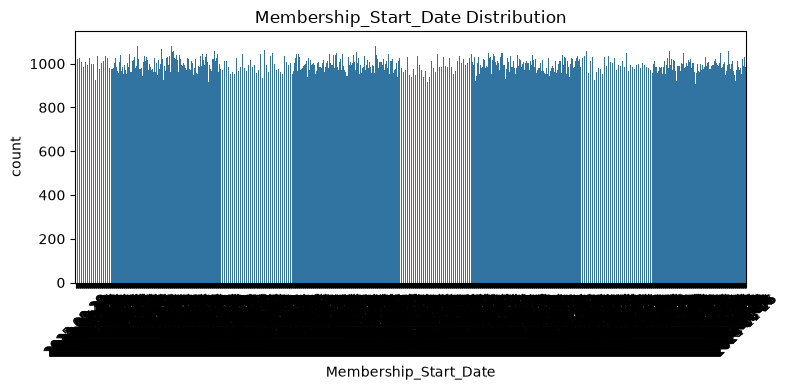

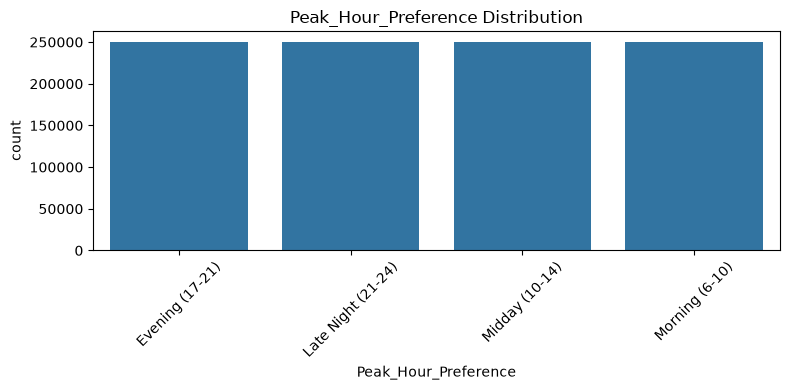

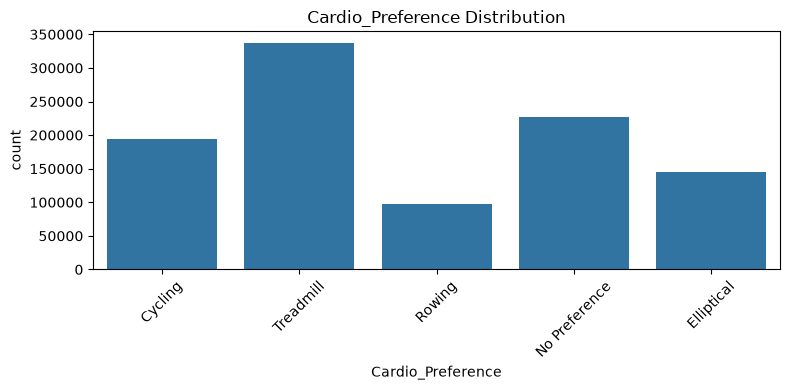

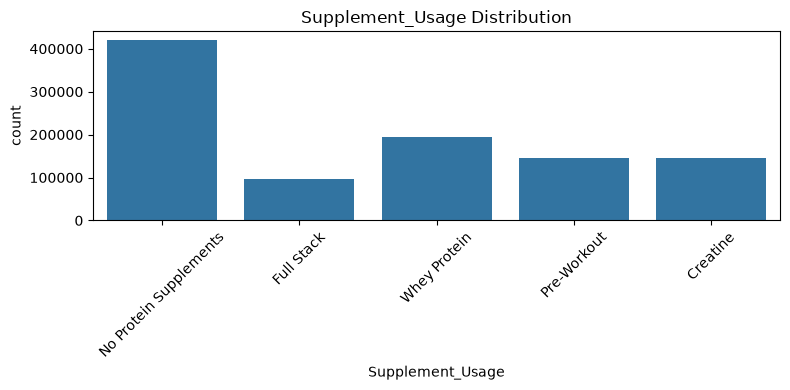

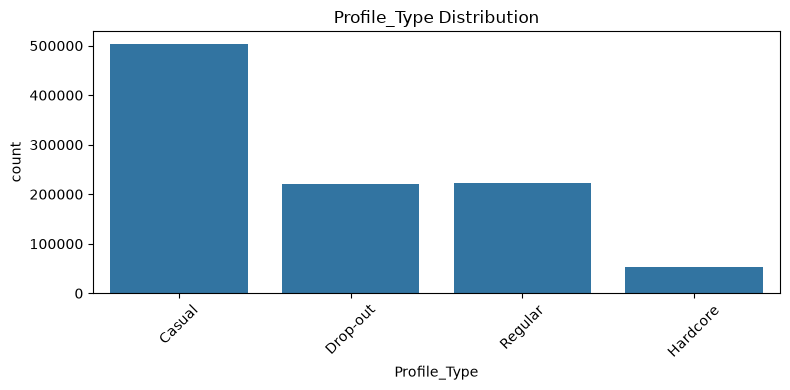

In [18]:
# 범주형 데이터 컬럼 선택
# 예: Gender, Membership_Type, Profile_Type 등
categorical_cols = churn.select_dtypes(include="str").columns


# 각 범주형 변수의 데이터 개수 확인
for col in categorical_cols:

    plt.figure(figsize=(8, 4))

    # 범주별 데이터 개수 시각화
    sns.countplot(
        data=churn,
        x=col
    )

    plt.title(f"{col} Distribution")

    # 범주명이 길 경우 회전
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

In [19]:
# 범주형 변수별 실제 개수 확인

for col in categorical_cols:

    print(f"\n===== {col} =====")

    # 각 범주의 데이터 개수 출력
    print(churn[col].value_counts())


===== Gender =====
Gender
Female    500002
Male      499998
Name: count, dtype: int64

===== Membership_Type =====
Membership_Type
Standard    449978
Gold        299987
Premium     200370
VIP          49665
Name: count, dtype: int64

===== Membership_Start_Date =====
Membership_Start_Date
2024-02-03    1093
2025-11-30    1091
2025-09-09    1080
2023-10-17    1080
2025-08-12    1079
              ... 
2023-06-13     916
2025-04-24     915
2024-07-15     915
2024-06-03     906
2025-01-24     904
Name: count, Length: 1005, dtype: int64

===== Peak_Hour_Preference =====
Peak_Hour_Preference
Midday (10-14)        250332
Late Night (21-24)    250218
Evening (17-21)       249851
Morning (6-10)        249599
Name: count, dtype: int64

===== Cardio_Preference =====
Cardio_Preference
Treadmill        337598
No Preference    226685
Cycling          193756
Elliptical       145220
Rowing            96741
Name: count, dtype: int64

===== Supplement_Usage =====
Supplement_Usage
No Protein Supplement

In [20]:
# 수치형 변수 간 상관계수 계산
# Pearson Correlation 사용
corr = churn.select_dtypes(include="number").corr()

# 상관관계 테이블 확인
corr

,Age,Monthly_Fee,Monthly_Visits,Avg_Workout_Duration_Min,Treadmill_Avg_Speed_Kmh,Treadmill_Avg_Incline_Pct,Group_Class_Attendance,PT_Session_Count,Avg_Equipment_Wait_Time_Min,Late_Payment_Count,Churn
Age,1.000000,0.000119,0.000499,0.000465,-0.000756,-0.000684,0.001258,-0.001463,0.000792,-0.000265,-0.034406
Monthly_Fee,0.000119,1.000000,-0.001876,-0.001425,0.000860,0.000843,-0.000043,0.000263,-0.000244,0.000585,-0.000108
Monthly_Visits,0.000499,-0.001876,1.000000,0.126705,-0.000121,-0.000465,0.076379,0.098536,0.079083,-0.000709,-0.123658
Avg_Workout_Duration_Min,0.000465,-0.001425,0.126705,1.000000,-0.001990,0.000544,0.131285,0.039993,0.141281,0.000458,-0.035897
Treadmill_Avg_Speed_Kmh,-0.000756,0.000860,-0.000121,-0.001990,1.000000,0.000865,-0.001208,-0.000903,0.002940,0.001070,0.001518
Treadmill_Avg_Incline_Pct,-0.000684,0.000843,-0.000465,0.000544,0.000865,1.000000,0.000432,-0.001525,0.000779,0.001423,-0.000411
Group_Class_Attendance,0.001258,-0.000043,0.076379,0.131285,-0.001208,0.000432,1.000000,0.024067,0.085796,-0.000587,-0.078448
PT_Session_Count,-0.001463,0.000263,0.098536,0.039993,-0.000903,-0.001525,0.024067,1.000000,0.025095,0.001233,-0.094206
Avg_Equipment_Wait_Time_Min,0.000792,-0.000244,0.079083,0.141281,0.002940,0.000779,0.085796,0.025095,1.000000,-0.000086,0.052618
Late_Payment_Count,-0.000265,0.000585,-0.000709,0.000458,0.001070,0.001423,-0.000587,0.001233,-0.000086,1.000000,0.224492


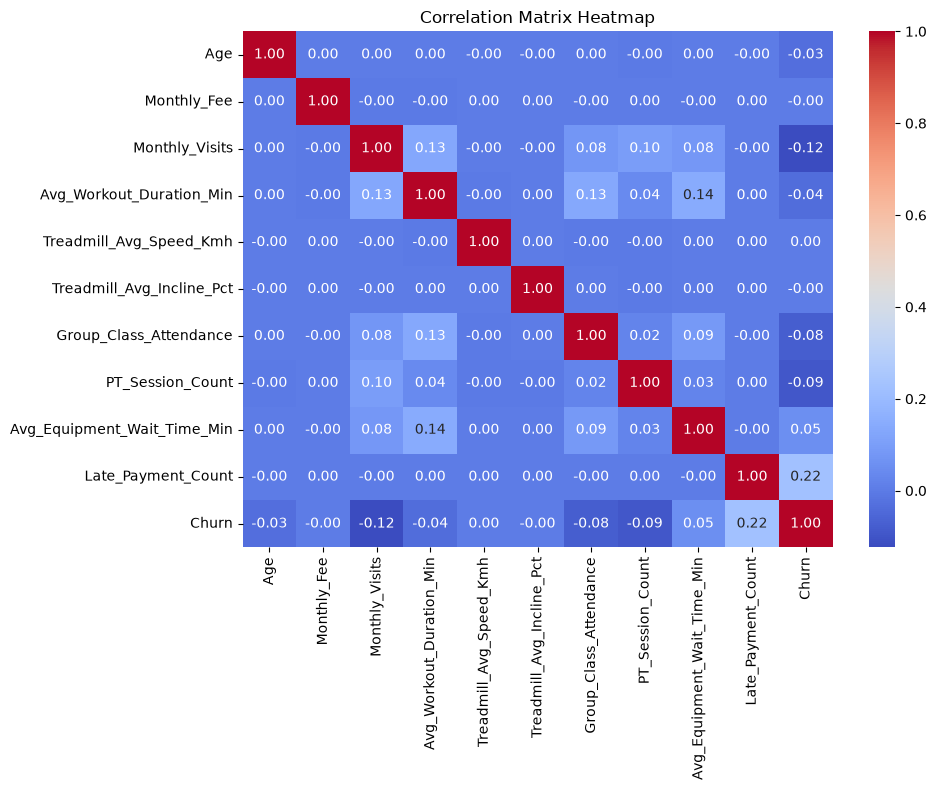

In [21]:
plt.figure(figsize=(10, 8))

# 상관관계를 색상으로 표현
# annot=True : 상관계수 숫자 표시
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix Heatmap")

plt.tight_layout()
plt.show()

In [22]:
# Churn과 다른 변수들의 상관관계 확인
# 값이 클수록 Churn과 양의 관계
# 값이 작을수록 음의 관계

churn_corr = corr["Churn"].sort_values(
    ascending=False
)

churn_corr

Churn                          1.000000
Late_Payment_Count             0.224492
Avg_Equipment_Wait_Time_Min    0.052618
Treadmill_Avg_Speed_Kmh        0.001518
Monthly_Fee                   -0.000108
Treadmill_Avg_Incline_Pct     -0.000411
Age                           -0.034406
Avg_Workout_Duration_Min      -0.035897
Group_Class_Attendance        -0.078448
PT_Session_Count              -0.094206
Monthly_Visits                -0.123658
Name: Churn, dtype: float64

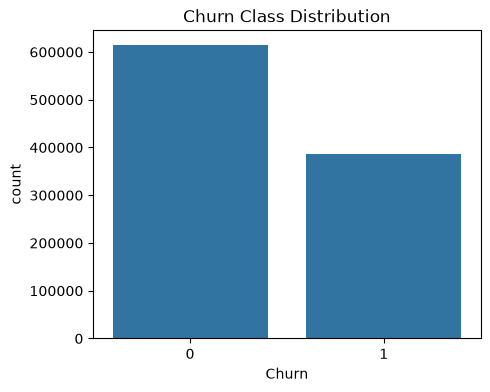

In [23]:
plt.figure(figsize=(5, 4))

# Churn 0 : 유지
# Churn 1 : 이탈

sns.countplot(
    data=churn,
    x="Churn"
)


plt.title("Churn Class Distribution")

plt.show()

In [24]:
# 각 클래스별 데이터 개수 확인

churn["Churn"].value_counts()

Churn
0    614298
1    385702
Name: count, dtype: int64

In [25]:
# 전체 데이터 대비 비율 확인

churn["Churn"].value_counts(
    normalize=True
) * 100

Churn
0    61.4298
1    38.5702
Name: proportion, dtype: float64

In [26]:
# 클래스별 개수와 비율 출력

class_count = churn["Churn"].value_counts()

class_ratio = (
    churn["Churn"]
    .value_counts(normalize=True)
    .round(3)
    * 100
)


print("===== Class Count =====")
print(class_count)


print("\n===== Class Ratio (%) =====")
print(class_ratio)

===== Class Count =====
Churn
0    614298
1    385702
Name: count, dtype: int64

===== Class Ratio (%) =====
Churn
0    61.4
1    38.6
Name: proportion, dtype: float64
